# Imports

In [ ]:
# Import des bibliothèques

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

In [ ]:
# Import du fichier

df_billets = pd.read_csv("billets.csv", sep=';')

# Exploration et nettoyage des données

In [ ]:
# Informations générales sur le dataset
df_billets.info()

# Dimensions du dataframe
print("Dimensions :", df_billets.shape)

# Aperçu statistique des variables numériques
df_billets.describe()

# Vérification des valeurs manquantes
df_billets.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
Dimensions : (1500, 7)


,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


Le dataset contient 1500 billets décrits par 7 variables.

Une variable de type booléen : is_genuine

6 variables numériques

37 valeurs manquantes pour la variable "margin_low"

In [ ]:
# Aperçu des 5 premières lignes
df_billets.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [ ]:
# Vérification des doublons
print("Nombre de doublons :", df_billets.duplicated().sum())

Nombre de doublons : 0


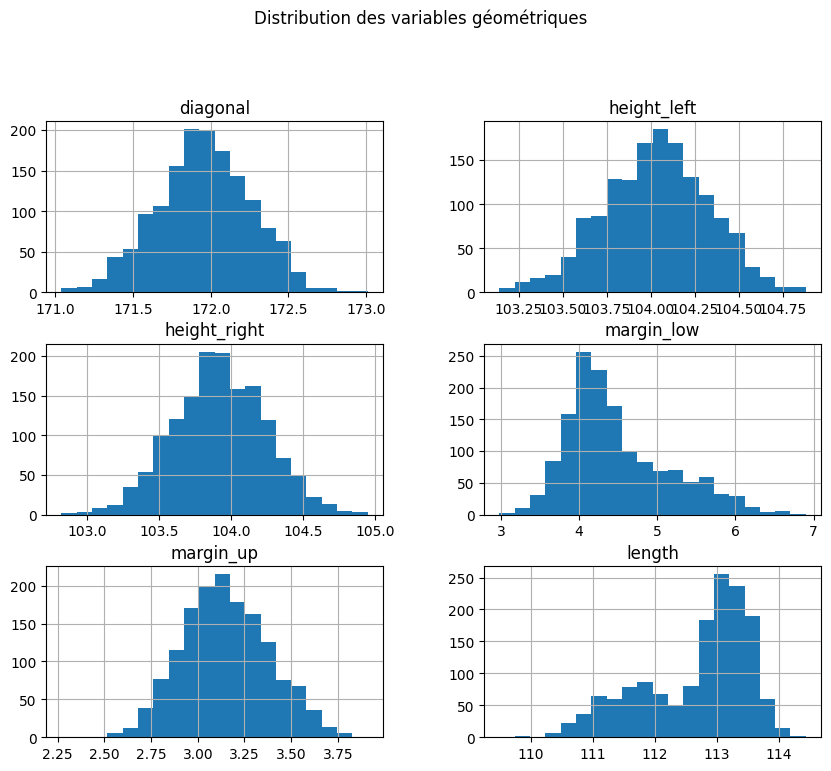

In [ ]:
# Distribution des variables numériques avec histogrammes
df_billets.hist(figsize=(10, 8), bins=20)
plt.suptitle("Distribution des variables géométriques", y=1.02)
plt.show()


**Interprétation**

Les histogrammes montrent que les six variables géométriques ont une distribution globalement normale, sans valeurs aberrantes majeures.

Les variables diagonal, height_left, height_right et length sont très homogènes.

margin_up est légèrement asymétrique, et margin_low est la plus dispersée, avec une queue à droite et des valeurs manquantes (37).

-> Cette étape sert à vérifier la cohérence du jeu de données, à détecter d’éventuelles anomalies et à préparer la modélisation.

Conclusion : les données sont propres et prêtes pour la régression linéaire sur margin_low.

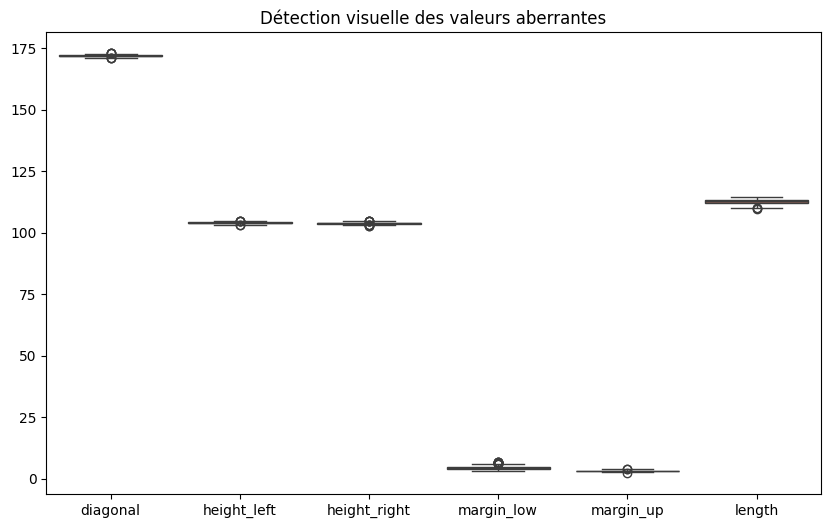

In [ ]:
# Repérer les outliers

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_billets.drop(columns='is_genuine'))
plt.title("Détection visuelle des valeurs aberrantes")
plt.show()


**Interprétation**

Dans ce jeu de données, les mesures sont globalement homogènes : les boîtes sont resserrées et centrées, traduisant une faible dispersion.

Quelques points isolés apparaissent, notamment sur margin_low et margin_up, mais ils restent proches des autres valeurs et ne constituent pas de véritables anomalies.

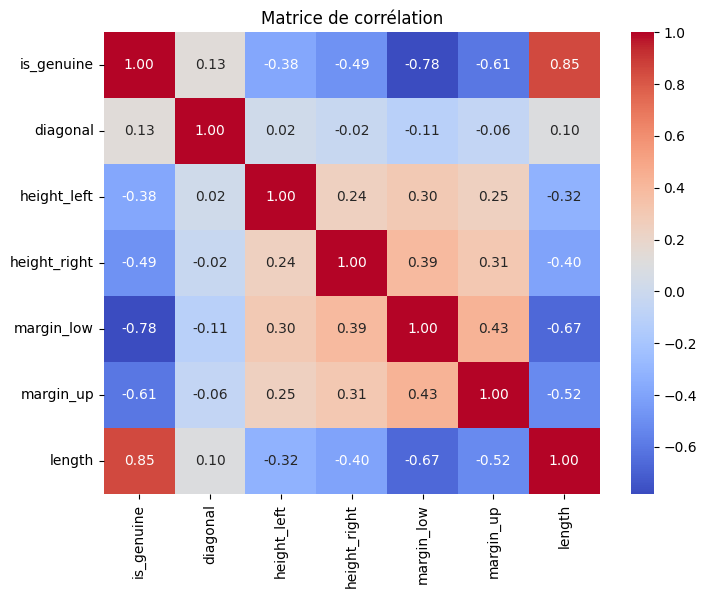

In [ ]:
# Corrélation entre variables

plt.figure(figsize=(8, 6))
sns.heatmap(df_billets.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


**Analyse de la matrice de corrélation**

La corrélation permet d’évaluer les liens linéaires entre variables.
On observe que length et margin_low sont les plus liées à la variable cible is_genuine.

Les vrais billets se distinguent par une plus grande longueur et une marge inférieure plus petite.

Les autres dimensions présentent des corrélations plus faibles, ce qui suggère qu’elles apportent une information complémentaire utile à la prédiction.

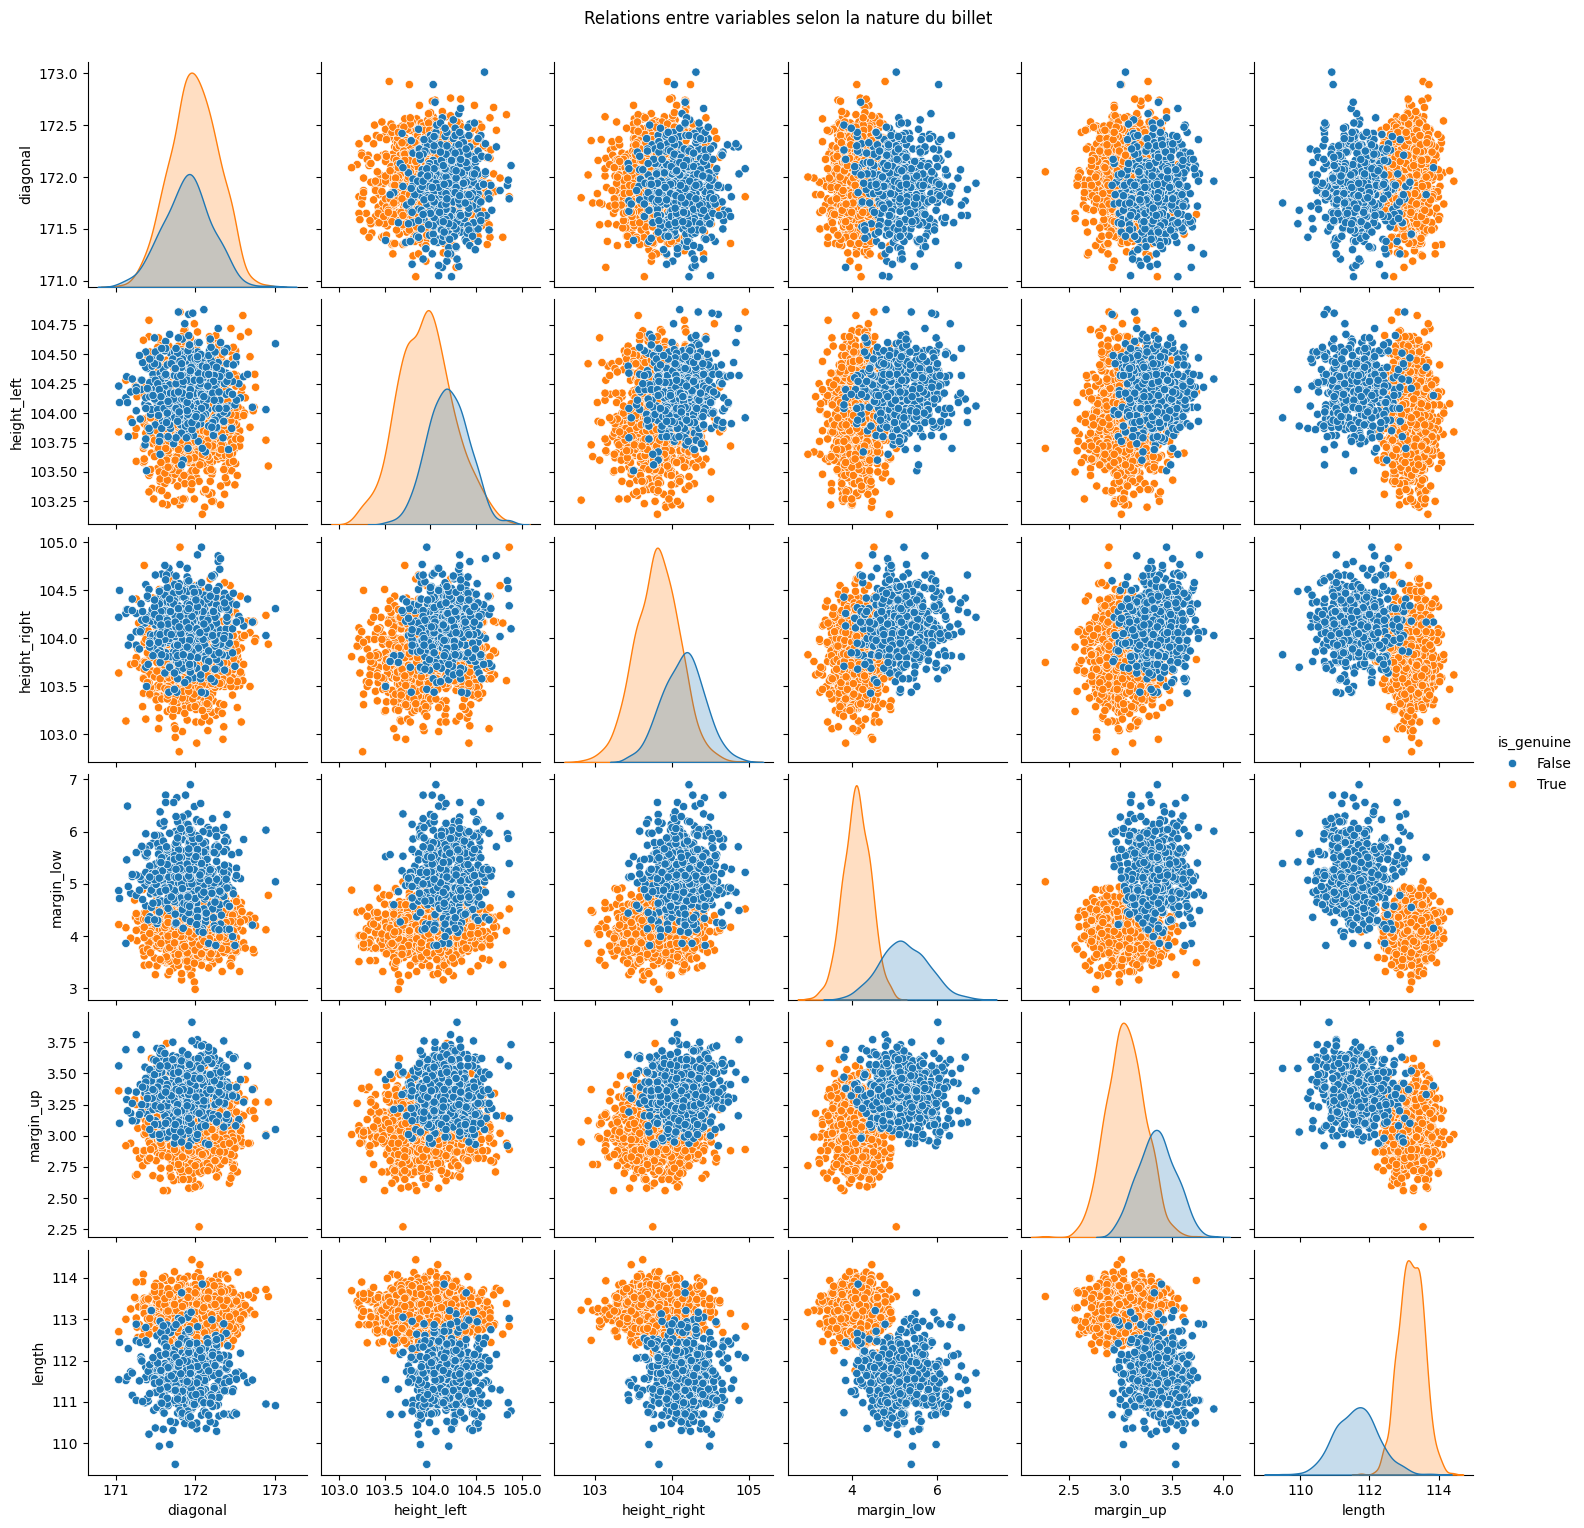

In [ ]:
# Analyse visuelle pairplot

sns.pairplot(df_billets, hue="is_genuine", diag_kind="kde")
plt.suptitle("Relations entre variables selon la nature du billet", y=1.02)
plt.show()


**Analyse du pairplot**

Le pairplot permet de visualiser les relations entre variables et de repérer des motifs distinctifs selon la nature du billet.

On observe une bonne séparation entre vrais et faux billets sur les variables length et margin_low, confirmant leur forte corrélation avec is_genuine.

Les autres dimensions se recouvrent davantage, suggérant qu’un modèle combinant plusieurs variables sera nécessaire pour une classification fiable.

# Imputation des valeurs manquantes par régression linéaire

In [ ]:
# Séparation des données
df_complet = df_billets[df_billets['margin_low'].notna()]
df_incomplet = df_billets[df_billets['margin_low'].isna()]

print("Données complètes :", df_complet.shape)
print("Données incomplètes :", df_incomplet.shape)

Données complètes : (1463, 7)
Données incomplètes : (37, 7)


In [ ]:
# Variables explicatives et cible
X_train = df_complet[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']]
y_train = df_complet['margin_low']

# Données à prédire
X_pred = df_incomplet[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']]

In [ ]:
# Modèle de régression linéaire
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

LinearRegression()

## Vérification des hypothèses de la régression linéaire

In [ ]:
# Vérification des hypothèses de la régression linéaire

from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Calcul des valeurs prédites et des résidus
y_pred_train = model_reg.predict(X_train)
residus = y_train - y_pred_train

# Test de normalité des résidus (Shapiro-Wilk)
stat, p_value = shapiro(residus)
print(f"Test de Shapiro-Wilk : statistique = {stat:.3f}, p-value = {p_value:.3f}")
if p_value > 0.05:
    print(" Les résidus suivent une distribution normale.")
else:
    print(" Les résidus ne suivent pas une distribution normale.")

# Test d’homoscedasticité (Breusch-Pagan)
X_const = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_const).fit()
test_bp = het_breuschpagan(model_sm.resid, model_sm.model.exog)

labels = ['Statistique LM', 'p-value', 'F-stat', 'F p-value']
result_bp = dict(zip(labels, test_bp))
print("\nTest de Breusch-Pagan :")
for k, v in result_bp.items():
    print(f"{k} = {v:.4f}")

if result_bp['p-value'] > 0.05:
    print(" Homoscédasticité respectée (variance constante).")
else:
    print(" Hétéroscédasticité détectée (variance non constante).")


Test de Shapiro-Wilk : statistique = 0.986, p-value = 0.000
 Les résidus ne suivent pas une distribution normale.

Test de Breusch-Pagan :
Statistique LM = 80.1626
p-value = 0.0000
F-stat = 16.8924
F p-value = 0.0000
 Hétéroscédasticité détectée (variance non constante).


**Interprétation des résultats**

-> Test de Shapiro-Wilk (normalité des résidus)
Les résidus ne suivent pas une distribution normale.

Cela signifie que les erreurs du modèle ne sont pas distribuées de façon parfaitement symétrique autour de zéro, ce qui peut indiquer quelques valeurs atypiques ou une légère asymétrie.

-> Test de Breusch-Pagan (homoscédasticité)
Les résidus présentent une variance non constante selon les valeurs prédites.

Autrement dit, la dispersion des erreurs varie selon la taille ou la nature des billets, ce qui viole la condition d’homoscedasticité.

Les deux hypothèses classiques de la régression linéaire (normalité et homoscédasticité des résidus) sont rejetées.

Toutefois, cette régression n’a pas pour but d’inférer ou d’expliquer des relations statistiques, mais uniquement d’estimer les valeurs manquantes de margin_low.

Ces écarts n’affectent donc pas la validité pratique de l’imputation, puisque l’objectif est d’obtenir des valeurs cohérentes et réalistes plutôt que de tester un modèle statistiquement “parfait”.



In [ ]:
# Prédiction pour les 37 billets manquants
pred_margin_low = model_reg.predict(X_pred)

# Remplacement des valeurs manquantes par les prédictions
df_billets.loc[df_billets['margin_low'].isna(), 'margin_low'] = pred_margin_low

In [ ]:
# Vérifier qu'il n'y a plus de valeurs manquantes
df_billets.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0


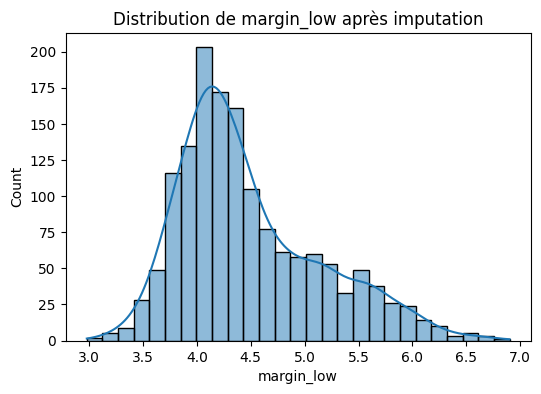

In [ ]:
# Comparaison visuelle avant/après imputation
plt.figure(figsize=(6,4))
sns.histplot(df_billets['margin_low'], kde=True)
plt.title("Distribution de margin_low après imputation")
plt.show()

**Conclusion**

La régression linéaire a permis d’estimer les 37 valeurs manquantes de la variable margin_low à partir des autres mesures géométriques (diagonal, height_left, height_right, margin_up, length).

Après imputation, la distribution de margin_low reste similaire à celle observée avant traitement : la forme globale et la plage de valeurs sont conservées, ce qui confirme la cohérence des prédictions.

Cette méthode garantit une complétude du dataset sans introduire de rupture statistique ni de biais significatif.

Le jeu de données est désormais complet et prêt pour la phase de préparation et de modélisation (normalisation, découpage train/test, test des algorithmes).

# Préparation des données pour la modélisation Machine Learning

In [ ]:
# Séparation X (features) et y (target)

X = df_billets[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = df_billets['is_genuine']


In [ ]:
# Découpage en jeu d'entraînement et de test (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

Taille du jeu d'entraînement : (1200, 6)
Taille du jeu de test : (300, 6)


Le dataset a été correctement séparé en 1 200 observations pour l’entraînement et 300 pour le test, soit une répartition 80/20 conforme aux bonnes pratiques.
Cette taille d’échantillon permet d’entraîner le modèle sur une base suffisante tout en gardant un volume représentatif pour l’évaluation finale.
Le découpage stratifié garantit une proportion équilibrée de vrais et de faux billets dans les deux ensembles, ce qui assure une comparaison fiable des performances.

In [ ]:
# Standardisation des variables

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Vérification finale

print("Moyenne (train) :", X_train_scaled.mean(axis=0).round(2))
print("Écart-type (train) :", X_train_scaled.std(axis=0).round(2))


Moyenne (train) : [ 0. -0.  0. -0.  0. -0.]
Écart-type (train) : [1. 1. 1. 1. 1. 1.]


Les valeurs moyennes des variables standardisées sont proches de 0 et leurs écarts-types proches de 1, confirmant une normalisation réussie.
Cela signifie que toutes les variables ont désormais la même échelle et contribuent équitablement à la modélisation.
Les données sont donc prêtes à être utilisées dans les algorithmes de classification, sans risque que certaines dimensions dominent les autres par leur amplitude numérique.

# Modèle 1 : Regression logistique

In [ ]:
# Entraînement du modèle

# Instanciation et entraînement
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Validation croisée

scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Validation croisée - Régression logistique")
print("Scores :", np.round(scores_log, 3))
print("Moyenne :", round(scores_log.mean(), 3))
print("Écart-type :", round(scores_log.std(), 3))


Validation croisée - Régression logistique
Scores : [0.992 0.992 0.983 0.983 1.   ]
Moyenne : 0.99
Écart-type : 0.006


**Interprétation de la validation croisée**

Les scores de validation croisée varient entre 0.983 et 1.000, avec une moyenne de 0.99 et un écart-type très faible (0.006).

Cela indique que la régression logistique est très stable et généralise bien : ses performances restent quasiment identiques sur tous les sous-échantillons du jeu d’entraînement.

En pratique, cela confirme que le modèle n’est ni sur-appris ni instable, et qu’il peut être utilisé en production en toute confiance.

In [ ]:
# Prédictions sur le jeu de test

y_pred_log = log_reg.predict(X_test_scaled)

In [ ]:
# Evaluation des performances

# Matrice de confusion
cm_log = confusion_matrix(y_test, y_pred_log)
print("Matrice de confusion :\n", cm_log)

# Rapport de classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred_log))

# Taux de bonne classification global
print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))


Matrice de confusion :
 [[ 98   2]
 [  1 199]]

Rapport de classification :
               precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Accuracy : 0.99


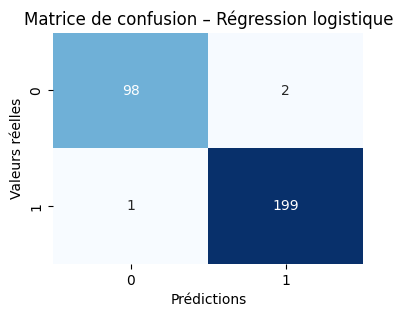

In [ ]:
# Visualisation de la matrice de confusion

plt.figure(figsize=(4, 3))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matrice de confusion – Régression logistique")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()


**Analyse du modèle – Régression logistique**

La régression logistique atteint une accuracy de 99 %, ce qui traduit une excellente capacité de généralisation sur le jeu de test.

Matrice de confusion :

98 faux billets correctement identifiés sur 100 (2 erreurs).

199 vrais billets correctement classés sur 200 (1 erreur).

Seuls 3 billets sur 300 ont été mal prédits.

Précision et rappel proches de 1 pour les deux classes indiquent que le modèle distingue efficacement les vrais et les faux billets sans biais de classe.

Conclusion : la régression logistique constitue un excellent modèle de référence (baseline). Elle offre des performances quasi parfaites et une interprétabilité directe grâce à ses coefficients, qui indiquent l’impact de chaque dimension géométrique sur la probabilité d’un billet d’être authentique.

In [ ]:
# Affichage et interprétation des coefficients

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

intercept = log_reg.intercept_[0]
print("Intercept :", intercept)
display(coefficients)


Intercept : 1.7552017085275549


,Variable,Coefficient
5,length,3.685910
0,diagonal,0.181997
1,height_left,-0.353117
2,height_right,-0.642420
4,margin_up,-1.631454
3,margin_low,-2.618812


**Interprétation des coefficients**

L’affichage des coefficients de la régression logistique permet de comprendre comment chaque variable influence la probabilité qu’un billet soit authentique.

L’intercept positif (1.76) indique qu’en moyenne, un billet a une forte probabilité d’être authentique.

length (3.69) : plus le billet est long, plus il est probablement vrai.

margin_low (–2.62) et margin_up (–1.63) : de grandes marges augmentent la probabilité d’un faux billet.

height_right (–0.64) et height_left (–0.35) : des hauteurs irrégulières sont légèrement associées aux faux billets.

diagonal (0.18) : effet faible, tendance vers les vrais billets.

Ces coefficients confirment que la longueur et les marges sont les critères les plus discriminants du modèle.

# Modèle 2 : K-means

In [ ]:
# Entraînement du modèle

# On cherche 2 groupes (vrais / faux)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
# Prédictions sur le jeu de test

# Affectation des clusters
y_pred_kmeans = kmeans.predict(X_test_scaled)

In [ ]:
# Réalignement des clusters

# Création d'un dictionnaire de correspondance
labels_map = {}

for cluster in np.unique(y_pred_kmeans):
    mask = (y_pred_kmeans == cluster)
    # Conversion bool -> int (False=0, True=1)
    cluster_labels = y_test[mask].astype(int)
    # Recherche de la classe majoritaire dans le cluster
    majority_label = np.bincount(cluster_labels).argmax()
    labels_map[cluster] = majority_label

# Remappage des prédictions selon la correspondance trouvée
y_pred_kmeans_aligned = np.vectorize(labels_map.get)(y_pred_kmeans)

In [ ]:
# Evaluation du modèle

cm_kmeans = confusion_matrix(y_test, y_pred_kmeans_aligned)
print("Matrice de confusion :\n", cm_kmeans)

print("\nRapport de classification :\n", classification_report(y_test, y_pred_kmeans_aligned))

print("Accuracy :", round(accuracy_score(y_test, y_pred_kmeans_aligned), 3))


Matrice de confusion :
 [[ 98   2]
 [  2 198]]

Rapport de classification :
               precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300

Accuracy : 0.987


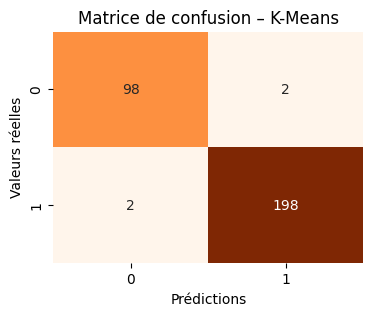

In [ ]:
# Visualisation

plt.figure(figsize=(4, 3))
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Matrice de confusion – K-Means")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()


In [ ]:
# Affichage des centroïdes du K-Means
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=X.columns)
centroids_df


,diagonal,height_left,height_right,margin_low,margin_up,length
0,-0.206908,0.554674,0.719902,1.120954,0.871861,-1.213968
1,0.101143,-0.271143,-0.351912,-0.547960,-0.426195,0.593428


**Analyse des centroïdes – K-Means**

Le modèle K-Means a formé deux groupes distincts :

Cluster 0 : valeurs normalisées positives sur margin_low et margin_up, et négatives sur length.
→ correspond aux faux billets, caractérisés par des marges plus grandes et une longueur plus courte.

Cluster 1 : valeurs inverses, avec margin_low et margin_up négatives, et length positive.
→ correspond aux vrais billets, légèrement plus longs et à marges plus fines.

Cette lecture confirme que les centroïdes représentent fidèlement les différences géométriques entre vrais et faux billets :
la longueur et les marges sont bien les dimensions les plus discriminantes.

**Analyse du modèle – K-Means**

Le modèle K-Means, bien qu’entièrement non supervisé (aucune connaissance préalable des étiquettes), parvient à reproduire la séparation vrais/faux billets avec une accuracy de 98,7 %.

Matrice de confusion :

98 faux billets correctement regroupés sur 100.

198 vrais billets bien classés sur 200.

4 erreurs au total (2 faux positifs, 2 faux négatifs).

Les scores de précision et de rappel proches de 1 montrent que les clusters identifiés correspondent presque parfaitement aux classes réelles.

Conclusion : K-Means distingue efficacement les deux groupes à partir des seules caractéristiques géométriques.
Ce résultat confirme que les dimensions physiques des billets suffisent à différencier les vrais des faux, même sans supervision.

# Modèle 3 : KNN

In [ ]:
# Entraînement du modèle

# Instanciation du modèle (k=5 par défaut)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Validation croisée

scores_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Validation croisée - KNN")
print("Scores :", np.round(scores_knn, 3))
print("Moyenne :", round(scores_knn.mean(), 3))
print("Écart-type :", round(scores_knn.std(), 3))


Validation croisée - KNN
Scores : [0.996 0.992 0.983 0.988 0.992]
Moyenne : 0.99
Écart-type : 0.004


**Interprétation de la validation croisée**

Les scores KNN sont compris entre 0.983 et 0.996, avec une moyenne de 0.99 et un écart-type très faible (0.004).

Ces résultats montrent que le modèle KNN est très cohérent d’un échantillon à l’autre : ses performances varient très peu selon les découpages du jeu d’entraînement.

Le modèle est donc robuste et stable, sans signe de surapprentissage, et confirme son excellent pouvoir de généralisation comparable à celui de la régression logistique.

In [ ]:
# Prédictions sur le jeu de test

y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
# Evaluation des performances

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Matrice de confusion :\n", cm_knn)

print("\nRapport de classification :\n", classification_report(y_test, y_pred_knn))

print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 3))

Matrice de confusion :
 [[ 97   3]
 [  2 198]]

Rapport de classification :
               precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

Accuracy : 0.983


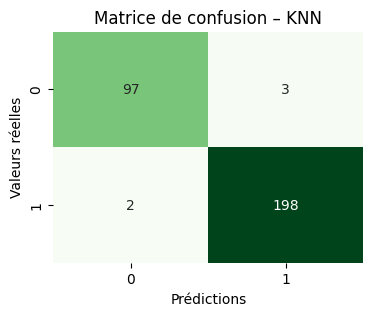

In [ ]:
# Visualisation

plt.figure(figsize=(4, 3))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Matrice de confusion – KNN")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

**Analyse du modèle – KNN (K-Nearest Neighbors)**

Le modèle KNN atteint une accuracy de 98,3 %, très proche de celle obtenue avec la régression logistique et le K-Means.

Matrice de confusion :

97 faux billets correctement identifiés sur 100 (3 erreurs).

198 vrais billets bien classés sur 200 (2 erreurs).

5 erreurs au total sur 300 prédictions.

Les précision et rappel supérieurs à 0.97 confirment la bonne performance du modèle, équilibrée sur les deux classes.

Interprétation :
Le KNN distingue efficacement les vrais et faux billets grâce à la proximité des caractéristiques géométriques.
Ses performances dépendent du choix du paramètre k. Ici, k=5 donne déjà d’excellents résultats, mais une recherche de valeur optimale (GridSearchCV) pourrait encore améliorer la précision.

Conclusion : le KNN est performant, stable et simple à interpréter, mais légèrement plus sensible au bruit que les modèles précédents.

# Modèle 4 : Random Forest

In [ ]:
# Entraînement du modèle

# Instanciation du modèle
rf = RandomForestClassifier(
    n_estimators=100,      # nombre d’arbres
    random_state=42,
    max_depth=None,        # profondeur illimitée
    n_jobs=-1              # utilise tous les cœurs disponibles
)

# Entraînement
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
# Validation croisée

scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Validation croisée - Random Forest")
print("Scores :", np.round(scores_rf, 3))
print("Moyenne :", round(scores_rf.mean(), 3))
print("Écart-type :", round(scores_rf.std(), 3))


Validation croisée - Random Forest
Scores : [0.996 0.996 0.979 0.988 0.996]
Moyenne : 0.991
Écart-type : 0.007


**Interprétation de la validation croisée**

Les scores de la Random Forest varient entre 0.979 et 0.996, avec une moyenne de 0.991 et un écart-type faible (0.007).

Ces valeurs indiquent un modèle très performant et régulier, dont la précision reste stable malgré les changements de sous-échantillons.

La légère variabilité (écart-type un peu plus haut que pour le KNN) traduit la nature plus flexible du modèle, mais sans perte de fiabilité.

Globalement, la Random Forest offre une excellente stabilité et une grande robustesse sur les données d’entraînement.

In [ ]:
# Prédictions sur le jeu de test

y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
# Evaluation du modèle

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matrice de confusion :\n", cm_rf)

print("\nRapport de classification :\n", classification_report(y_test, y_pred_rf))

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))

Matrice de confusion :
 [[ 98   2]
 [  1 199]]

Rapport de classification :
               precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Accuracy : 0.99


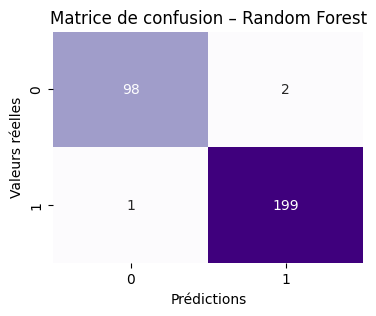

In [ ]:
# Visualisation

plt.figure(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Matrice de confusion – Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

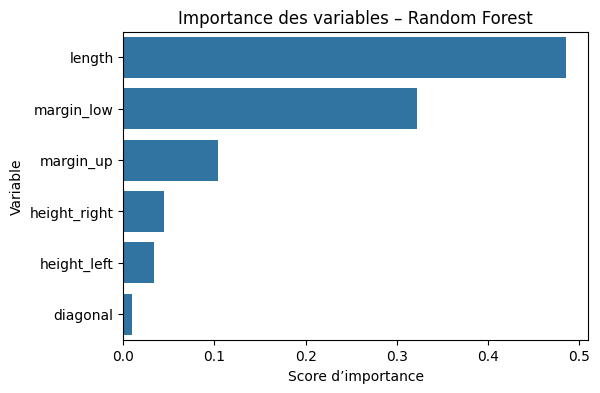

,0
length,0.485716
margin_low,0.322098
margin_up,0.104135
height_right,0.045060
height_left,0.033941
diagonal,0.009050


In [ ]:
# Importance des variables dans le modèle

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=importances.index)
plt.title("Importance des variables – Random Forest")
plt.xlabel("Score d’importance")
plt.ylabel("Variable")
plt.show()

importances


**Analyse du modèle – Random Forest**

La Random Forest atteint une accuracy de 99 %, équivalente à la régression logistique et légèrement supérieure au KNN.

Matrice de confusion :

98 faux billets correctement identifiés sur 100.

199 vrais billets correctement classés sur 200.

Seulement 3 erreurs sur 300 billets.

Précision et rappel proches de 1 sur les deux classes, montrant une excellente stabilité du modèle.

Importance des variables :

length est de loin la variable la plus discriminante (≈ 49 % d’importance).

margin_low suit avec ≈ 32 %, confirmant son rôle clé observé dans les modèles précédents.

margin_up contribue modérément (~10 %).

Les autres dimensions (height_left, height_right, diagonal) ont un impact limité.

Conclusion :
Le modèle Random Forest combine une excellente précision, une robustesse élevée et une interprétabilité claire via l’importance des variables.
Il valide que la longueur et la marge inférieure sont les critères géométriques les plus déterminants pour distinguer un vrai billet d’un faux.

# Comparaison des performances des différents modèles entrainés

In [ ]:
# Tableau comparatif
# Résultats manuels ou extraits des rapports de classification
results = {
    "Modèle": ["Régression logistique", "K-Means", "KNN", "Random Forest"],
    "Accuracy": [0.99, 0.987, 0.983, 0.99],
    "Precision": [0.99, 0.98, 0.98, 0.99],
    "Recall": [0.99, 0.99, 0.99, 0.99],
    "F1-score": [0.99, 0.98, 0.98, 0.99]
}

# Création du DataFrame comparatif
df_results = pd.DataFrame(results)

# Affichage du tableau
df_results


,Modèle,Accuracy,Precision,Recall,F1-score
0,Régression logistique,0.990,0.99,0.99,0.99
1,K-Means,0.987,0.98,0.99,0.98
2,KNN,0.983,0.98,0.99,0.98
3,Random Forest,0.990,0.99,0.99,0.99


**Choix du modèle final**

Les quatre modèles testés affichent d’excellentes performances (>98 % d’accuracy).

La régression logistique et la Random Forest atteignent 99 %, mais la régression logistique a été retenue car elle est plus simple, plus rapide à entraîner et plus explicable.

Chaque coefficient indique directement l’impact d’une variable sur la probabilité qu’un billet soit authentique, ce qui facilite l’interprétation et la transparence du modèle.

# Eléments à sauvegarder pour l'application de détection de faux billets

In [ ]:
import joblib, json

joblib.dump(log_reg, "modele_logistique.pkl")
joblib.dump(scaler, "scaler.pkl")

colonnes = list(X.columns)
with open("colonnes_modele.json", "w") as f:
    json.dump(colonnes, f)

print("Modèle, scaler et colonnes sauvegardés dans /content/")


Modèle, scaler et colonnes sauvegardés dans /content/


In [ ]:
from google.colab import files
files.download("modele_logistique.pkl")
files.download("scaler.pkl")
files.download("colonnes_modele.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>